In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from IPython.display import HTML

In [14]:
def select_by_latlon(ds, lat_target, lon_target):
    lat = ds['nav_lat'].values
    lon = ds['nav_lon'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return ds.isel(y=y_idx, x=x_idx)

In [15]:
from OceanDataStore import OceanDataCatalog

In [16]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [17]:
catalog.available_collections

['noc-rapid-evolution', 'noc-npd-jra55', 'noc-npd-era5']

In [18]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [19]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d']

In [20]:
catalog.Items[3]

<Item id=noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d>

In [21]:
ds1 = catalog.open_dataset(id=catalog.Items[3].id,
                          start_datetime='1976-01',
                          end_datetime='2024-12',                        
                          bbox = (-85.0, 0.0, 0.0, 80.0))

In [22]:
### Using Monthly Means, from 1976 

plt.close('all')

septembers = []
for year in range (1976, 2025):
    septembers.append(f'{year}-09-15')

marches = []
for year in range (1976, 2025):
    marches.append(f'{year}-03-15')

september_data = ds1['tos_con'].sel(time_counter=septembers, method='nearest')
march_data = ds1['tos_con'].sel(time_counter=marches, method = 'nearest')

september_data['time_counter'] = september_data['time_counter'].dt.year
march_data['time_counter'] = march_data['time_counter'].dt.year
Amplitudes = (september_data - march_data).compute()

x index = 23
y index = 297


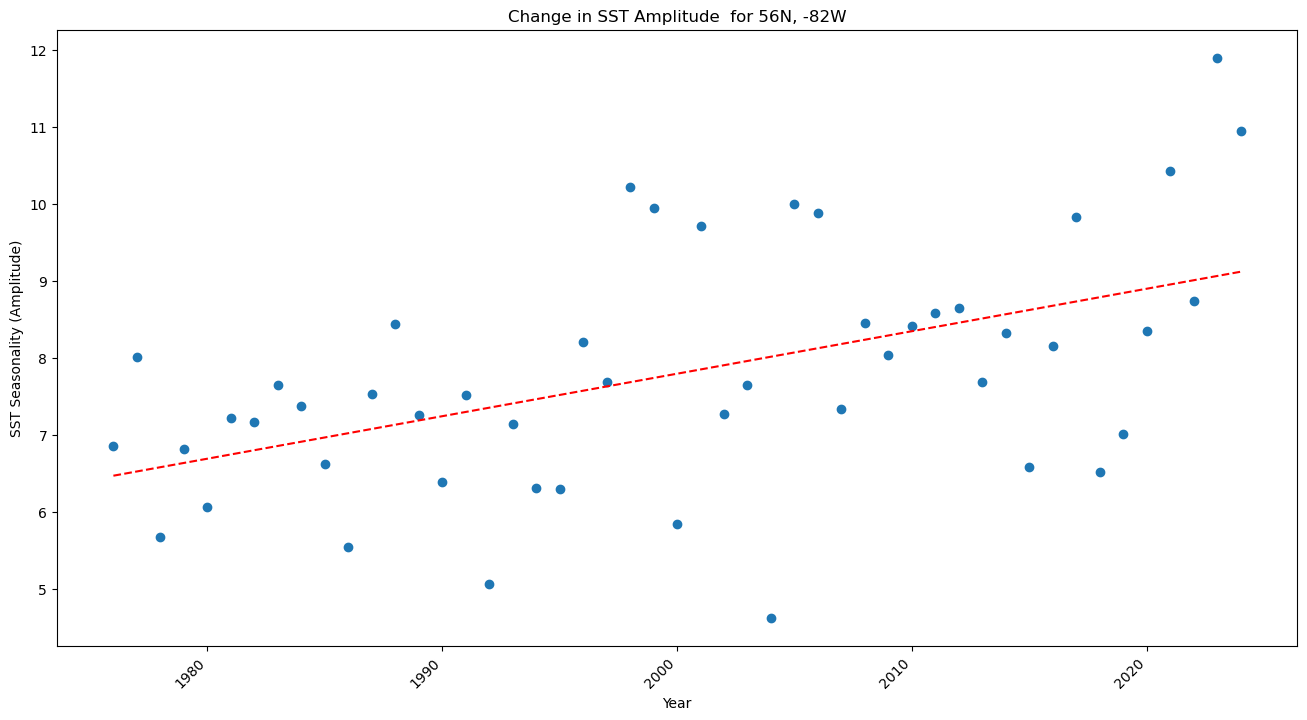

In [11]:
random_point = select_by_latlon(Amplitudes, 56.0, -82.0)

fig, ax = plt.subplots(figsize = (16,8))
ax.scatter(random_point['time_counter'], random_point.values)

z = np.polyfit(random_point['time_counter'], random_point.values, 1)
p = np.poly1d(z)
ax.plot(random_point['time_counter'] ,p(random_point['time_counter']),"r--")

ax.set_xlabel('Year')
ax.set_ylabel('SST Seasonality (Amplitude)')
ax.set_title('Change in SST Amplitude  for 56N, -82W')
plt.xticks(rotation=45, ha='right')
plt.show()

x index = 256
y index = 291


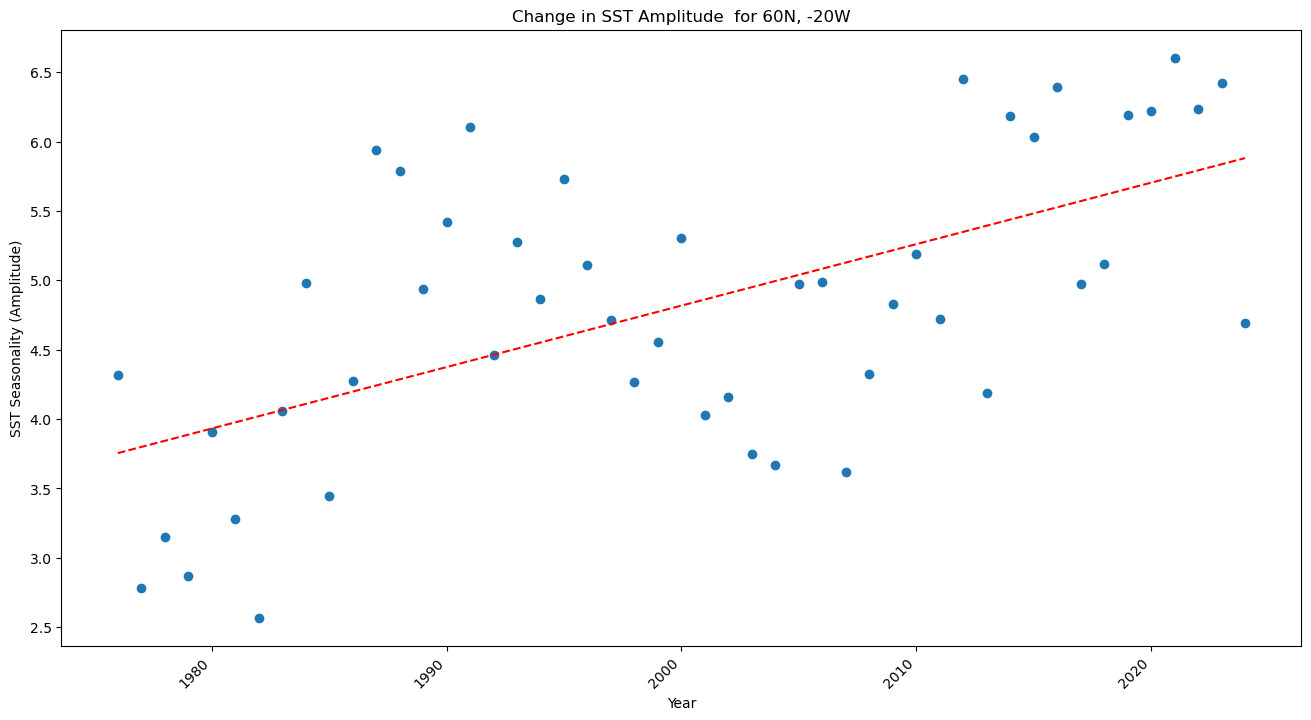

In [12]:
random_point2 = select_by_latlon(Amplitudes, 60, -20)

fig, ax = plt.subplots(figsize = (16,8))
ax.scatter(random_point2['time_counter'], random_point2.values)

z = np.polyfit(random_point2['time_counter'], random_point2.values, 1)
p = np.poly1d(z)
ax.plot(random_point2['time_counter'] ,p(random_point2['time_counter']),"r--")

ax.set_xlabel('Year')
ax.set_ylabel('SST Seasonality (Amplitude)')
ax.set_title('Change in SST Amplitude  for 60N, -20W')
plt.xticks(rotation=45, ha='right')
plt.show()

x index = 180
y index = 82


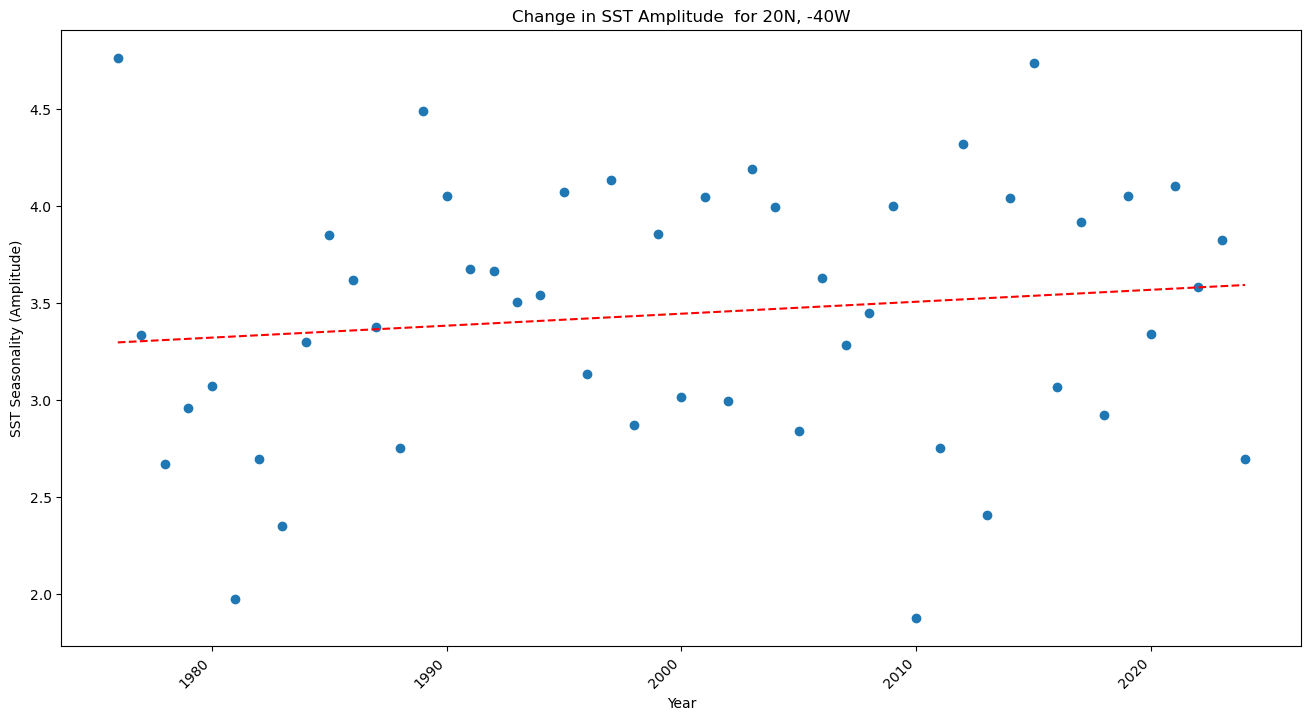

In [13]:
random_point3 = select_by_latlon(Amplitudes, 20, -40)

fig, ax = plt.subplots(figsize = (16,8))
ax.scatter(random_point3['time_counter'], random_point3.values)

z = np.polyfit(random_point3['time_counter'], random_point3.values, 1)
p = np.poly1d(z)
ax.plot(random_point3['time_counter'] ,p(random_point3['time_counter']),"r--")

ax.set_xlabel('Year')
ax.set_ylabel('SST Seasonality (Amplitude)')
ax.set_title('Change in SST Amplitude  for 20N, -40W')
plt.xticks(rotation=45, ha='right')
plt.show()

x index = 141
y index = 191


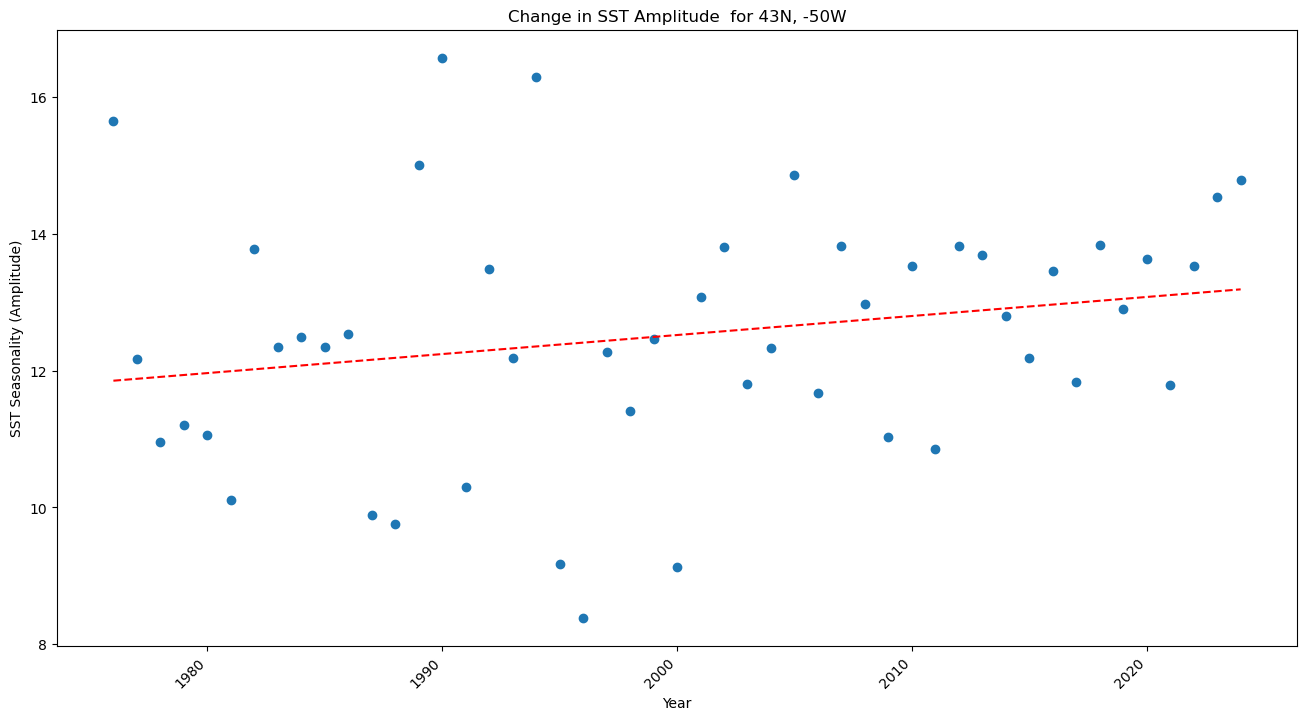

In [14]:
random_point4 = select_by_latlon(Amplitudes, 43.0, -50.0)

fig, ax = plt.subplots(figsize = (16,8))
ax.scatter(random_point4['time_counter'], random_point4.values)

z = np.polyfit(random_point4['time_counter'], random_point4.values, 1)
p = np.poly1d(z)
ax.plot(random_point4['time_counter'] ,p(random_point4['time_counter']),"r--")

ax.set_xlabel('Year')
ax.set_ylabel('SST Seasonality (Amplitude)')
ax.set_title('Change in SST Amplitude  for 43N, -50W')
plt.xticks(rotation=45, ha='right')
plt.show()

In [23]:
## Calculating map of trend magnitudes 

ny, nx = Amplitudes.sizes['y'], Amplitudes.sizes['x']
trend_data = np.full((ny, nx), np.nan, dtype=np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        point = Amplitudes.isel(y=y_idx, x=x_idx)
        try:
            z = np.polyfit(point['time_counter'], point.values, 1)
            trend_data[y_idx, x_idx] = z[0]
        except:
            trend_data[y_idx, x_idx] = np.nan

trend_da = xr.DataArray(data = trend_data, dims=["y", "x"], 
        coords={ "y": Amplitudes['y'],
        "x": Amplitudes['x'],
        "nav_lat": (("y", "x"), Amplitudes['nav_lat'].values),
        "nav_lon": (("y", "x"), Amplitudes['nav_lon'].values)}, name="trend",
        attrs={"description": "Linear trend over time of SST amplitude"})
        

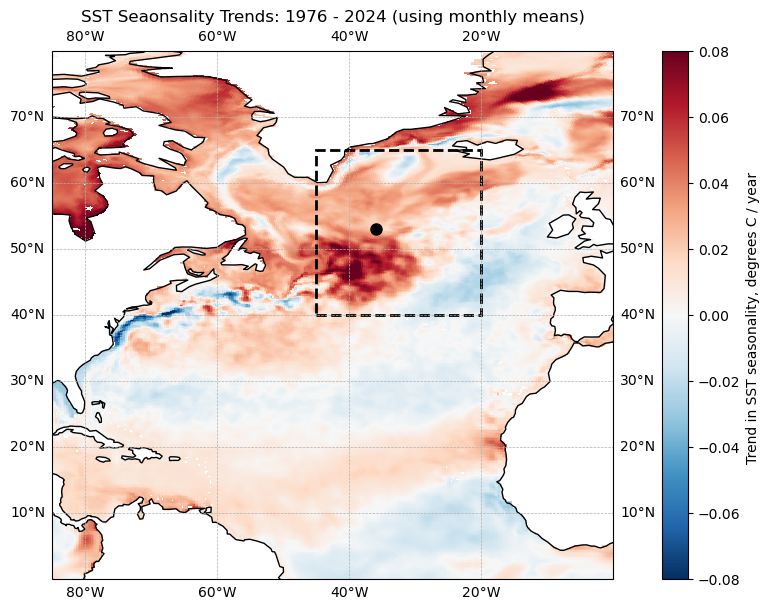

In [24]:
## Plotting Map of Trend Magnitude

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))
im = ax.pcolormesh(trend_da['nav_lon'], trend_da['nav_lat'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin= -0.08, vmax=0.08)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', 
                facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Trend in SST seasonality, degrees C / year ')
plt.tight_layout()
title = ax.set_title('SST Seaonsality Trends: 1976 - 2024 (using monthly means)')

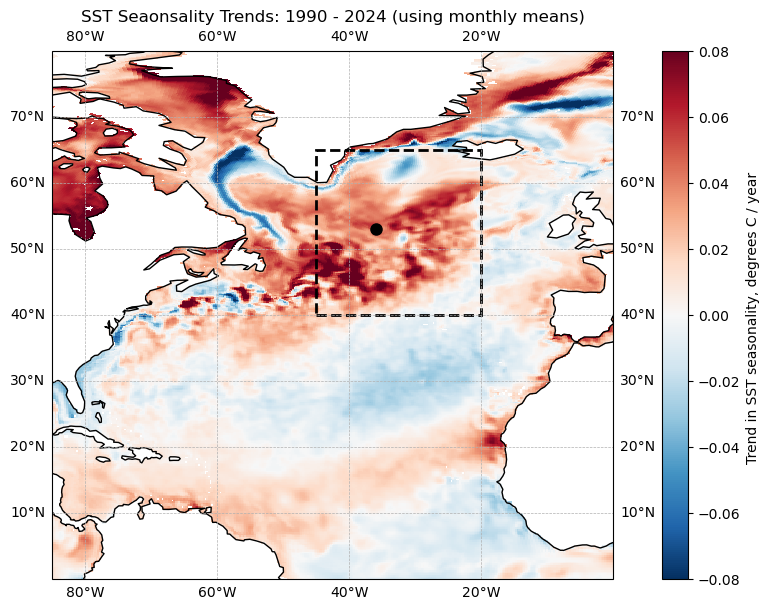

In [11]:
### Using Monthly means, from 1990

Amplitudes_subset = Amplitudes.sel(time_counter = slice(1990, 2024))

ny, nx = Amplitudes_subset.sizes['y'], Amplitudes_subset.sizes['x']
trend_data = np.full((ny, nx), np.nan, dtype=np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        point = Amplitudes_subset.isel(y=y_idx, x=x_idx)
        try:
            z = np.polyfit(point['time_counter'], point.values, 1)
            trend_data[y_idx, x_idx] = z[0]
        except:
            trend_data[y_idx, x_idx] = np.nan

trend_da = xr.DataArray(data = trend_data, dims=["y", "x"], 
        coords={ "y": Amplitudes_subset['y'],
        "x": Amplitudes_subset['x'],
        "nav_lat": (("y", "x"), Amplitudes_subset['nav_lat'].values),
        "nav_lon": (("y", "x"), Amplitudes_subset['nav_lon'].values)}, name="trend",
        attrs={"description": "Linear trend over time of SST amplitude"})

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))
im = ax.pcolormesh(trend_da['nav_lon'], trend_da['nav_lat'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin= -0.08, vmax=0.08)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', 
                facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Trend in SST seasonality, degrees C / year ')
plt.tight_layout()
title = ax.set_title('SST Seaonsality Trends: 1990 - 2024 (using monthly means)')

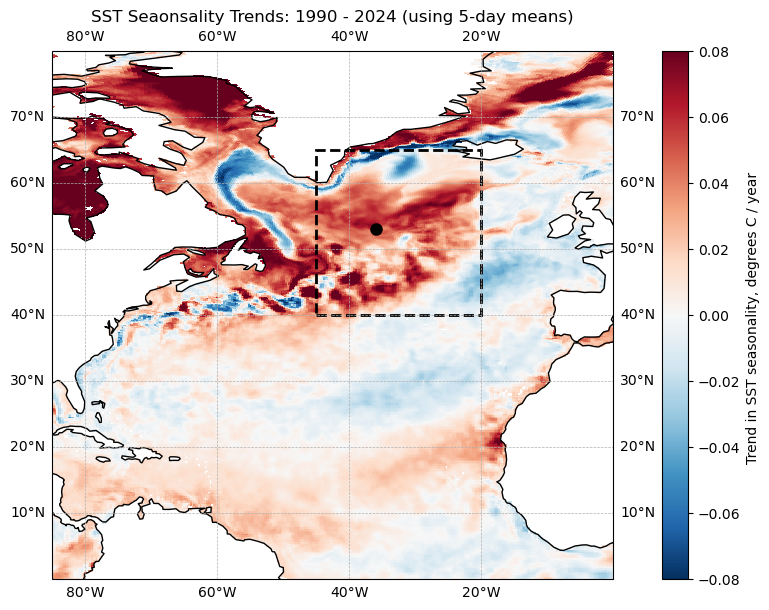

In [12]:
## Using 5-day means, from 1990 - extend scale 
ds2 = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12',                        
                          bbox = (-85.0, 0.0, 0.0, 80.0))

min_region = ds2.sel(time_counter = ds2['time_counter'].dt.month.isin([2, 3, 4]))
max_region = ds2.sel(time_counter = ds2['time_counter'].dt.month.isin([8, 9, 10]))
min_temp = ((min_region['tos_con'].groupby('time_counter.year')).min(dim='time_counter'))
max_temp = ((max_region['tos_con'].groupby('time_counter.year')).max(dim='time_counter'))
Amplitudes_5day = (max_temp - min_temp).compute()

ny, nx = Amplitudes_5day.sizes['y'], Amplitudes_5day.sizes['x']
trend_data = np.full((ny, nx), np.nan, dtype=np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        point = Amplitudes_5day.isel(y=y_idx, x=x_idx)
        try:
            z = np.polyfit(point['year'], point.values, 1)
            trend_data[y_idx, x_idx] = z[0]
        except:
            trend_data[y_idx, x_idx] = np.nan

trend_da = xr.DataArray(data = trend_data, dims=["y", "x"], 
        coords={ "y": Amplitudes_5day['y'],
        "x": Amplitudes_5day['x'],
        "nav_lat": (("y", "x"), Amplitudes_5day['nav_lat'].values),
        "nav_lon": (("y", "x"), Amplitudes_5day['nav_lon'].values)}, name="trend",
        attrs={"description": "Linear trend over time of SST amplitude"})

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))
im = ax.pcolormesh(trend_da['nav_lon'], trend_da['nav_lat'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin= -0.08, vmax=0.08)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', 
                facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Trend in SST seasonality, degrees C / year ')
plt.tight_layout()
title = ax.set_title('SST Seaonsality Trends: 1990 - 2024 (using 5-day means)')